# Data Exploration: Welltory COVID-19 and Wearables Dataset

**Ben Dushnitzky — AIPI 510, Week 4**

This notebook explores the Welltory COVID-19 open dataset — what is in it, where it is broken, and what
would need cleaning before modelling it. I focus on heart rate variability (HRV), since that is what the
study was built around and it is the table that links to everything else.

## 1. Data Context and Sampling

**Source.** https://github.com/Welltory/hrv-covid19, released under Creative Commons with a `CONSENT`
file and a `datatypes.md` data dictionary, which is what I used to decode the column names.

**Who collected it and why.** Welltory is a consumer health app that measures HRV. In 2020 they asked
users with COVID-19 symptoms to keep logging measurements and symptoms so researchers could look for
patterns in how the disease progressed.

**How it was collected** — three different methods are mixed together, which matters for interpretation:

1. **HRV** — either a Bluetooth chest strap or the phone camera using photoplethysmography (PPG), where
   you hold a finger over the lens and the app detects blood volume changes. PPG is noisier, and no
   column records which method was used.
2. **Wearables** — whatever device the user already owned (Apple Watch, Garmin) via Apple Health or
   Google Fit. Different vendors measure different things, which is why most wearable columns are empty.
3. **Symptoms** — typed in by the user, with no validation at entry.

**Lineage.** Raw beat intervals → Welltory's own filtering → the metrics stored here. These are
*processed* values, and I cannot audit their algorithm. The `rr_data` column does keep the raw beat
intervals, which gives me a way to sanity-check the output.

**Sampling.** This is a **convenience sample**, not a random one. Everyone here owned a smartphone,
installed a health app, and volunteered. That means selection bias toward younger, wealthier,
health-conscious people, and anyone too sick to use their phone is missing entirely. There is no control
group, COVID status is self-reported in an era when testing was scarce, and participants chose when to
measure.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

if not os.path.exists("hrv-covid19"):
    os.system("git clone --depth 1 https://github.com/Welltory/hrv-covid19.git")
DATA = "hrv-covid19/data/"

participants = pd.read_csv(DATA + "participants.csv")
hrv          = pd.read_csv(DATA + "hrv_measurements.csv", low_memory=False)
surveys      = pd.read_csv(DATA + "surveys.csv")
scales       = pd.read_csv(DATA + "scales_description.csv")
wearables    = pd.read_csv(DATA + "wearables.csv")
heart_rate   = pd.read_csv(DATA + "heart_rate.csv", low_memory=False)

tables = {"participants": participants, "hrv_measurements": hrv, "surveys": surveys,
          "scales_description": scales, "wearables": wearables, "heart_rate": heart_rate}

pd.DataFrame([{"table": n, "rows": len(d), "columns": d.shape[1],
               "users": d["user_code"].nunique() if "user_code" in d.columns else None}
              for n, d in tables.items()])

,table,rows,columns,users
0,participants,185,8,185.0
1,hrv_measurements,3245,22,185.0
2,surveys,2259,5,111.0
3,scales_description,148,4,NaN
4,wearables,3098,18,79.0
5,heart_rate,523783,4,79.0


## 2. Data Structure and What the Features Mean

Everything joins on `user_code`, the anonymised participant ID. `participants` is one row per person,
the rest are one row per measurement or per day. `scales_description` is a codebook explaining what the
numeric `value` in `surveys` means.

Coverage is very uneven — 185 people produced 3,245 HRV measurements but 523,783 heart rate readings.
Joining everything into one table would leave most of it empty, so I keep them separate.

HRV is the variation in time between heartbeats. A rested body varies a lot; stress and illness flatten
it out. The columns split into two groups:

| Column | Meaning |
|---|---|
| `meanrr` | Mean interval between beats (ms). `bpm` is just 60000 / meanrr |
| `sdnn` | SD of beat intervals — overall HRV |
| `rmssd` | Root mean square of successive differences — short-term HRV, parasympathetic ("rest and digest") |
| `pnn50` | % of consecutive beats differing by more than 50ms — also parasympathetic |
| `mode`, `amo` | Most common interval, and share of beats in that bin. High `amo` means a rigid, stressed rhythm |
| `hf` | High frequency power (0.15–0.4 Hz) — tracks breathing, parasympathetic |
| `lf` | Low frequency power (0.04–0.15 Hz) — mixed |
| `vlf` | Very low frequency power (below 0.04 Hz) |
| `lfhf` | LF/HF ratio, sometimes called "sympathovagal balance" |
| `total_power` | Total spectral power |

`how_feel`, `how_mood` and `how_sleep` are self-ratings given at measurement time, and `tags` are free
labels like "COVID-19" or "Workout". Note that `rmssd`, `pnn50` and `hf` all measure roughly the same
thing, so they should be strongly correlated — I check that later.

In [2]:
print(hrv.shape)
display(hrv.drop(columns=["rr_data"]).head(3))
hrv.drop(columns=["rr_data"]).dtypes.to_frame("dtype").T

(3245, 22)


,user_code,rr_code,measurement_datetime,time_of_day,bpm,meanrr,mxdmn,sdnn,rmssd,pnn50,mode,amo,lf,hf,vlf,lfhf,total_power,how_feel,how_mood,how_sleep,tags
0,007b8190cf,10489a6aea,2020-04-21 21:23:08,morning,75,795.9,0.12,45.802,54.174,15.15,0.775,53.0,508.0,1076.0,267.0,0.472,1851.0,0,-1,NaN,COVID-19; Workout; Sex; Hobby; Studying; Sleep...
1,007b8190cf,9610d4d4dc,2020-04-26 11:19:25,morning,70,858.0,0.11,32.889,33.022,16.16,0.875,54.0,409.0,310.0,176.0,1.319,895.0,0,0,0.0,NaN
2,013f6d3e5b,f3de056155,2020-05-15 04:14:21,night,83,724.1,0.17,54.811,65.987,17.17,0.725,46.0,432.0,881.0,194.0,0.490,1507.0,-1,-2,NaN,COVID-19; Fast/Diet; Hungry; Tired; Fever; I c...


,user_code,rr_code,measurement_datetime,time_of_day,bpm,meanrr,mxdmn,sdnn,rmssd,pnn50,mode,amo,lf,hf,vlf,lfhf,total_power,how_feel,how_mood,how_sleep,tags
dtype,str,str,str,str,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,float64,str


## 3. Descriptive Statistics

In [3]:
hrv_cols = ["bpm", "meanrr", "sdnn", "rmssd", "pnn50", "amo",
            "lf", "hf", "vlf", "lfhf", "total_power"]
display(hrv[hrv_cols].describe().T.round(2))
hrv[hrv_cols].skew().sort_values(ascending=False).round(2).to_frame("skew")

,count,mean,std,min,25%,50%,75%,max
bpm,3245.0,73.26,12.20,44.00,65.00,72.00,81.00,125.00
meanrr,3245.0,839.60,137.42,477.73,742.49,829.10,925.93,1346.74
sdnn,3245.0,52.49,29.37,9.52,32.58,46.92,64.41,206.63
rmssd,3245.0,52.81,39.35,6.34,28.98,42.87,62.48,310.80
pnn50,3245.0,20.62,18.59,0.00,6.06,16.16,29.29,91.92
amo,3245.0,46.79,16.42,12.00,35.00,45.00,57.00,98.00
lf,3245.0,927.04,1455.42,2.00,151.00,423.00,1059.00,15522.00
hf,3245.0,1125.04,2490.54,4.00,158.00,380.00,993.00,33490.00
vlf,3245.0,578.23,876.68,1.00,116.00,293.00,693.00,18468.00
lfhf,3245.0,2.40,5.75,0.03,0.40,0.86,1.97,105.62


,skew
lfhf,7.98
vlf,6.05
hf,5.34
lf,3.80
total_power,3.79
rmssd,2.66
sdnn,1.72
pnn50,1.41
amo,0.53
bpm,0.48


The time-domain columns look sensible: `bpm` runs 44–125 with mean 73 and median 72, roughly symmetric.

The frequency columns are a different story. `hf` runs from 4 to 33,490 with a **mean of 1,125 but a
median of only 380**. When the mean is three times the median the distribution has a long right tail, and
the skew values confirm it — `vlf` 6.1, `hf` 5.3, `lf` 3.8.

This is real physiology, not corruption. But it means the mean and standard deviation are misleading for
these columns, and any outlier rule based on standard deviations will misfire. I come back to this in the
outlier and transformation sections.

## 4. Data Quality Assessment

The short version: this dataset is structurally sound, but the content has real problems and almost all
of them come from the self-reported columns.

In [4]:
# Profiling and completeness
rows = []
for name, df in tables.items():
    worst = df.isna().mean().idxmax()
    rows.append({"table": name,
                 "overall_missing_%": round(df.isna().mean().mean() * 100, 1),
                 "emptiest_column": worst,
                 "that_column_%": round(df[worst].isna().mean() * 100, 1)})
display(pd.DataFrame(rows).sort_values("overall_missing_%", ascending=False))
(wearables.isna().mean() * 100).round(1).sort_values(ascending=False).head(6).to_frame("missing_%")

,table,overall_missing_%,emptiest_column,that_column_%
4,wearables,48.2,average_spo2_value,98.7
1,hrv_measurements,4.0,how_sleep,54.8
0,participants,3.9,symptoms_onset,20.5
2,surveys,0.0,user_code,0.0
3,scales_description,0.0,Scale,0.0
5,heart_rate,0.0,user_code,0.0


,missing_%
average_spo2_value,98.7
body_temperature_avg,97.9
average_environment_exposure,95.2
average_headphone_exposure,92.6
stand_hours_total,82.9
active_calories_burned,61.3


In [5]:
# Accuracy: bpm should equal 60000/meanrr by definition, so this checks the data against itself
gap = (hrv["bpm"] - 60000 / hrv["meanrr"]).abs()
print("median disagreement:", round(gap.median(), 3), "bpm")
print("rows off by more than 5 bpm:", (gap > 5).sum())

# Accuracy of the self-reported dates, which have no such check
onset = pd.to_datetime(participants["symptoms_onset"], format="%m/%d/%Y", errors="coerce")
hrv_dt = pd.to_datetime(hrv["measurement_datetime"])
print()
print("symptom onset dates range:", onset.min().date(), "to", onset.max().date())
print("but the study only ran: ", hrv_dt.min().date(), "to", hrv_dt.max().date())
impossible = onset[(onset < "2019-12-01") | (onset > "2020-07-01")]
print("impossible onset dates:", len(impossible))
print(sorted(impossible.dt.date.tolist()))

median disagreement: 0.332 bpm
rows off by more than 5 bpm: 0

symptom onset dates range: 1967-01-30 to 2022-04-21
but the study only ran:  2019-12-31 to 2020-06-19
impossible onset dates: 13
[datetime.date(1967, 1, 30), datetime.date(1968, 8, 15), datetime.date(1975, 3, 28), datetime.date(1977, 11, 20), datetime.date(1981, 11, 26), datetime.date(1982, 12, 16), datetime.date(1984, 4, 5), datetime.date(1987, 7, 7), datetime.date(1993, 1, 1), datetime.date(1999, 3, 6), datetime.date(2000, 6, 7), datetime.date(2021, 4, 1), datetime.date(2022, 4, 21)]


In [6]:
# Consistency: the codebook should join to surveys on the scale name
print("codebook keys with hidden whitespace:", [s for s in scales["Scale"].unique() if s != s.strip()])
print("scales missing from codebook, raw join:", sorted(set(surveys["scale"]) - set(scales["Scale"])))
print("scales missing after stripping:      ", sorted(set(surveys["scale"]) - set(scales["Scale"].str.strip())))

# Consistency of units
hw = participants[["height", "weight"]].dropna().head(4).copy()
hw["height_inches"] = (hw["height"] / 2.54).round(2)
hw["weight_pounds"] = (hw["weight"] * 2.20462).round(2)
display(hw)

# Integrity: every user_code should exist in participants
known = set(participants["user_code"])
for name, df in tables.items():
    if "user_code" in df.columns:
        print(f"{name:20s} users={df['user_code'].nunique():4d}  orphaned={len(set(df['user_code']) - known)}")
print("duplicate user_code in participants:", participants["user_code"].duplicated().sum())

codebook keys with hidden whitespace: ['S_HRA_MONTH\n\xa0']
scales missing from codebook, raw join: []
scales missing after stripping:       []


,height,weight,height_inches,weight_pounds
0,170.18,96.162,67.00,212.00
1,174.00,77.300,68.50,170.42
2,178.00,92.000,70.08,202.83
3,169.00,60.000,66.54,132.28


participants         users= 185  orphaned=0
hrv_measurements     users= 185  orphaned=0
surveys              users= 111  orphaned=0
wearables            users=  79  orphaned=0
heart_rate           users=  79  orphaned=0
duplicate user_code in participants: 0


**Completeness.** `average_spo2_value` is 98.7% missing and `body_temperature_avg` 97.9%, but that is not
corruption — those columns only fill if the participant owned a device that measures them, and in early
2020 almost nobody did. `basal_calories_burned` is 0% missing because every platform reports it. So the
data is **missing not at random**: whether a value exists depends on which device someone could afford.

**Accuracy.** `bpm` matches `60000/meanrr` to within 0.33 bpm, with zero rows off by more than 5. The
machine-derived columns are internally consistent and trustworthy.

The self-reported columns are not. **Thirteen participants gave symptom onset dates outside the study
period entirely** — 1967, 1984, 1999, 2021, 2022 — for a study that ran December 2019 to June 2020. These
were free-text entries, and the clustering in the 1960s–1990s suggests people typed a birth date. This is
the most serious accuracy problem here, because `symptoms_onset` anchors any timeline analysis.

**Consistency.** One codebook key is stored as `'S_HRA_MONTH\n\xa0'` — a trailing newline plus a
non-breaking space, probably pasted from a spreadsheet. Every scale does have an entry, but only after
stripping; the obvious join would silently drop rows instead of erroring. Separately, heights and weights
convert to exactly round imperial numbers (170.18 cm is exactly 67 inches, 96.162 kg is exactly 212
pounds), so people entered a mix of units and everything was converted on import. The three decimal
places are a conversion artifact, not real precision.

**Integrity** is clean — no orphaned keys, no duplicate participant IDs. The relational structure is fine.

**Lineage and provenance:**

| Stage | What happens | Consequence |
|---|---|---|
| Collection | Phone camera (PPG) or chest strap | Two methods with different noise levels, and no column says which |
| Processing | Welltory's own filtering | Can't audit it, but `rr_data` allows a sanity check |
| Wearables | Third-party devices via Apple Health / Google Fit | Different vendors, different definitions |
| Self-report | Users typing into the app | No validation — this is where the 1967 date came from |
| Publication | Anonymised, Creative Commons | No way to verify against a medical record |

**So: trust the HRV columns most, wearables moderately, self-reported columns least.**

## 5. Handling Missing Values

My rule here is that **the reason a value is missing decides what to do about it**. Imputing into a cell
that is empty for a structural reason invents data.

In [7]:
for col in ["how_feel", "how_mood", "how_sleep"]:
    print(col, "->", dict(hrv[col].value_counts(dropna=False).sort_index()))
print()
pd.crosstab(hrv["time_of_day"], hrv["how_sleep"].isna(),
            rownames=["time_of_day"], colnames=["how_sleep missing"])

how_feel -> {-2: np.int64(124), -1: np.int64(857), 0: np.int64(1975), 1: np.int64(237), 2: np.int64(52)}
how_mood -> {-2: np.int64(96), -1: np.int64(471), 0: np.int64(2335), 1: np.int64(272), 2: np.int64(71)}
how_sleep -> {-2.0: np.int64(50), -1.0: np.int64(238), 0.0: np.int64(967), 1.0: np.int64(180), 2.0: np.int64(31), nan: np.int64(1779)}



how_sleep missing,False,True
time_of_day,,
day,25,781
evening,0,701
morning,1440,27
night,1,270


**A trap worth pointing out.** `how_feel` and `how_mood` contain -1 and -2, which look like sentinel codes
for missing data. They are not — the values run -2, -1, 0, 1, 2 with most of the mass at 0, which is a
five-point Likert scale. Dropping the negatives would delete exactly the measurements taken when people
felt bad, which is the whole point of the study.

The crosstab shows `how_sleep` is filled for nearly every morning measurement and almost never otherwise.
It is **missing by design** because it is only asked in the morning, so imputing it would be inventing an
answer to a question that was never asked.

In [8]:
plan = pd.DataFrame([
    ["how_feel / how_mood", "0%", "Likert scale points, not sentinels", "Leave untouched"],
    ["how_sleep", "54.8%", "Only asked in the morning", "Leave missing"],
    ["tags", "32.2%", "No tag entered means none selected", "Fill with empty string"],
    ["symptoms_onset", "20.5%", "Never reported", "Leave missing"],
    ["average_spo2_value", "98.7%", "Device didn't support it", "Drop column"],
    ["body_temperature_avg", "97.9%", "Device didn't support it", "Drop column"],
], columns=["column", "missing", "why", "decision"])
display(plan)

hrv_clean = hrv.copy()
hrv_clean["tags"] = hrv_clean["tags"].fillna("")
too_sparse = wearables.columns[wearables.isna().mean() > 0.90]
wearables_clean = wearables.drop(columns=too_sparse)
print("dropped from wearables:", list(too_sparse))

,column,missing,why,decision
0,how_feel / how_mood,0%,"Likert scale points, not sentinels",Leave untouched
1,how_sleep,54.8%,Only asked in the morning,Leave missing
2,tags,32.2%,No tag entered means none selected,Fill with empty string
3,symptoms_onset,20.5%,Never reported,Leave missing
4,average_spo2_value,98.7%,Device didn't support it,Drop column
5,body_temperature_avg,97.9%,Device didn't support it,Drop column


dropped from wearables: ['average_spo2_value', 'body_temperature_avg', 'average_headphone_exposure', 'average_environment_exposure']


**Why I do not impute the sparse wearable columns.** The obvious move would be a median fill. That is
wrong here, because whether `average_spo2_value` exists depends on whether the participant could afford a
device that measures it. Filling with the median of the people who could afford one would assign their
physiology to everyone else, and a model trained on that would be learning about income, not health.

## 6. Removing Duplicates

No table has a fully duplicated row, so `drop_duplicates()` on its own finds nothing. The duplicates are
on the natural keys instead — same person, same timestamp.

In [9]:
keys = {"heart_rate": ["user_code", "datetime"],
        "hrv_measurements": ["user_code", "measurement_datetime"],
        "surveys": ["user_code", "scale", "created_at"],
        "wearables": ["user_code", "day"]}
display(pd.DataFrame([{"table": n, "exact_duplicate_rows": d.duplicated().sum(),
                       "duplicates_on_key": d.duplicated(keys[n]).sum() if n in keys else None}
                      for n, d in tables.items()]))

heart_rate[heart_rate.duplicated(["user_code", "datetime"], keep=False)].sort_values(
    ["user_code", "datetime"]).head(4)

,table,exact_duplicate_rows,duplicates_on_key
0,participants,0,NaN
1,hrv_measurements,0,0.0
2,surveys,0,24.0
3,scales_description,0,NaN
4,wearables,0,0.0
5,heart_rate,0,7330.0


,user_code,datetime,heart_rate,is_resting
68,01bad5a519,2020-05-12 20:56:53,65,0
69,01bad5a519,2020-05-12 20:56:53,66,0
72,01bad5a519,2020-05-14 03:37:01,68,0
73,01bad5a519,2020-05-14 03:37:01,69,0


In [10]:
# Average the heart rate collisions rather than keeping the first one arbitrarily
heart_rate_clean = (heart_rate.groupby(["user_code", "datetime"], as_index=False)
                    .agg({"heart_rate": "mean", "is_resting": "max"}))
# For repeated survey answers, keep the later one - a repeat is usually a correction
surveys_clean = surveys.drop_duplicates(["user_code", "scale", "created_at"], keep="last")
print("heart_rate:", len(heart_rate), "->", len(heart_rate_clean))
print("surveys:   ", len(surveys), "->", len(surveys_clean))

heart_rate: 523783 -> 516453
surveys:    2259 -> 2235


**Rationale.** The 7,330 heart rate collisions are a sync artifact — the same reading imported twice from
two sources, or the device reporting twice in one second. I average them because with two genuine
readings the mean is the better estimate, and picking one arbitrarily just adds noise. The 24 survey
collisions are the same person answering the same question twice in a day, so I keep the later answer on
the assumption that a repeat is a correction.

## 7. Handling Outliers

The key distinction is between values that are **extreme but real** and values that are **impossible**.
HRV is naturally skewed, so aggressive outlier removal would delete the unusual physiology the study
exists to find.

In [11]:
# What would a naive 3-sigma rule throw away?
naive = {c: (((hrv[c] - hrv[c].mean()) / hrv[c].std()).abs() > 3).sum() for c in hrv_cols}
display(pd.Series(naive).sort_values(ascending=False).head(6).to_frame("rows a 3-sigma rule would cut"))

# Instead, check physiological limits - values that cannot be true
checks = {"bpm outside 30-220": ((hrv["bpm"] < 30) | (hrv["bpm"] > 220)).sum(),
          "meanrr outside 300-2000ms": ((hrv["meanrr"] < 300) | (hrv["meanrr"] > 2000)).sum(),
          "sdnn <= 0": (hrv["sdnn"] <= 0).sum(),
          "rmssd <= 0": (hrv["rmssd"] <= 0).sum(),
          "pnn50 outside 0-100": ((hrv["pnn50"] < 0) | (hrv["pnn50"] > 100)).sum()}
pd.Series(checks).to_frame("rows violating")

,rows a 3-sigma rule would cut
rmssd,103
total_power,94
hf,89
pnn50,84
sdnn,82
lf,74


,rows violating
bpm outside 30-220,0
meanrr outside 300-2000ms,0
sdnn <= 0,0
rmssd <= 0,0
pnn50 outside 0-100,0


A 3-sigma rule would cut dozens of measurements, but every one of those values is physiologically
achievable — a very relaxed person really can have `hf` power in the thousands. Because these
distributions are right-skewed, the standard deviation is inflated by the tail itself, so the rule flags
ordinary high readings. **Deleting them would be discarding signal, not cleaning.** The right response to
skew is a transform, which I do in the next section.

The HRV table passes every physiological check with zero violations — Welltory's filtering did its job.
The problems are in the tables that were not filtered that way.

In [12]:
# heart_rate was not filtered the same way
hr_bad = (heart_rate_clean["heart_rate"] < 25) | (heart_rate_clean["heart_rate"] > 250)
print("heart_rate range:", heart_rate_clean["heart_rate"].min(), "-", heart_rate_clean["heart_rate"].max())
print("impossible readings removed:", hr_bad.sum())
heart_rate_clean = heart_rate_clean[~hr_bad]

# Heights that cannot be real
tall = participants["height"] > 220
print()
display(participants.loc[tall, ["user_code", "height", "weight"]])
participants_clean = participants.copy()
participants_clean.loc[tall, "height"] = np.nan

heart_rate range: 10.0 - 232.0
impossible readings removed: 89



,user_code,height,weight
49,3fff7627ca,248.92,114.713
102,83161408c1,250.00,82.146


**The most instructive error in the dataset.** Two participants are recorded above 220 cm, one at 250 cm
(8 foot 2) weighing 82 kg. That gives a BMI of 13.1 — low, but not obviously absurd, so a BMI-based
outlier filter would **miss it completely**. The error is only visible in the component, not in the
derived value. I set the height to missing rather than dropping the participant, since their HRV
measurements are still fine.

## 8. Data Transformation

Two transformations. First, a **log transform** on the skewed power metrics — they are bounded at zero
with long right tails, which is the textbook case, and it is also the convention in the HRV literature
(papers report `ln(RMSSD)` and `ln(HF)`), so it makes my numbers comparable to published work.

Second, **within-person standardisation**. Resting HRV varies enormously between people — a fit
25-year-old might sit at RMSSD 80 and a 60-year-old at 20, neither of them ill. If I pool everyone, that
between-person variation drowns out the within-person changes the study is actually about. A z-score
computed within each participant asks the right question: is this unusual *for them*?

In [13]:
log_cols = ["sdnn", "rmssd", "lf", "hf", "vlf", "total_power"]
for c in log_cols:
    hrv_clean["log_" + c] = np.log(hrv_clean[c])
display(pd.DataFrame({"skew_before": hrv_clean[log_cols].skew().round(2),
                      "skew_after": hrv_clean[["log_" + c for c in log_cols]].skew()
                                    .set_axis(log_cols).round(2)}))

hrv_clean["measurement_datetime"] = pd.to_datetime(hrv_clean["measurement_datetime"])
hrv_clean["date"] = hrv_clean["measurement_datetime"].dt.normalize()

# Within-person z-score, only for people with enough measurements for a baseline to mean anything
enough = hrv_clean.groupby("user_code")["rmssd"].transform("count") >= 5
hrv_clean["rmssd_z"] = np.nan
hrv_clean.loc[enough, "rmssd_z"] = (hrv_clean.loc[enough].groupby("user_code")["log_rmssd"]
                                    .transform(lambda s: (s - s.mean()) / s.std()))
print("participants with 5+ measurements:", hrv_clean.loc[enough, "user_code"].nunique(), "of 185")

,skew_before,skew_after
sdnn,1.72,-0.06
rmssd,2.66,0.30
lf,3.80,-0.27
hf,5.34,0.22
vlf,6.05,-0.38
total_power,3.79,-0.02


participants with 5+ measurements: 85 of 185


Skew drops from as high as 6.1 down to roughly zero. No offset was needed since every minimum is already
above zero.

## 9. Feature Engineering: `days_since_onset`

**What it is.** For each HRV measurement, the number of days between it and the participant's reported
symptom onset. Negative is before symptoms, 0 is onset day, positive is during or after illness.

**Why.** Calendar dates are useless for comparing people — one person got sick in March and another in
May, so 15 April means nothing in common. What the research question needs is *where in their own
illness* each measurement sits, which puts everyone on a shared timeline so "day 3 of illness" becomes
comparable across participants.

**The catch.** It depends entirely on `symptoms_onset`, the least reliable column in the dataset. So the
anchor has to be cleaned first — this is where the earlier data quality work pays off.

In [14]:
# Clean the anchor before using it
onset_clean = pd.to_datetime(participants_clean["symptoms_onset"], format="%m/%d/%Y", errors="coerce")
in_window = onset_clean.between(pd.Timestamp("2019-12-01"), pd.Timestamp("2020-07-01"))
participants_clean["onset_date"] = onset_clean.where(in_window)
print("onset dates reported:", onset_clean.notna().sum(),
      "| rejected as impossible:", (onset_clean.notna() & ~in_window).sum(),
      "| usable:", participants_clean["onset_date"].notna().sum())

# Build the feature
hrv_clean = hrv_clean.merge(participants_clean[["user_code", "onset_date"]], on="user_code", how="left")
hrv_clean["days_since_onset"] = (hrv_clean["date"] - hrv_clean["onset_date"]).dt.days
print("measurements with a timeline position:", hrv_clean["days_since_onset"].notna().sum(),
      "of", len(hrv_clean))
print()
print(hrv_clean["days_since_onset"].describe().round(1).to_string())

# Second feature: BMI, which only works because of the height cleaning above
participants_clean["bmi"] = participants_clean["weight"] / (participants_clean["height"] / 100) ** 2
print()
print("BMI computed for", participants_clean["bmi"].notna().sum(), "participants, median",
      round(participants_clean["bmi"].median(), 1))

onset dates reported: 147 | rejected as impossible: 13 | usable: 134
measurements with a timeline position: 2685 of 3245

count    2685.0
mean        9.8
std        46.8
min      -128.0
25%        -9.0
50%        20.0
75%        40.0
max        97.0

BMI computed for 181 participants, median 26.3


Cleaning the anchor first is what makes this usable — before it, the range ran from -726 to 19,465 days,
which would have meant someone measuring their HRV 53 years after catching COVID. After filtering it is
sensible.

I keep a wide window rather than trimming to just the illness period, because the measurements from
*before* onset are the most valuable rows here: they are the personal baseline that makes it possible to
say whether HRV actually dropped.

## 10. Visual Exploration and Variable Relationships

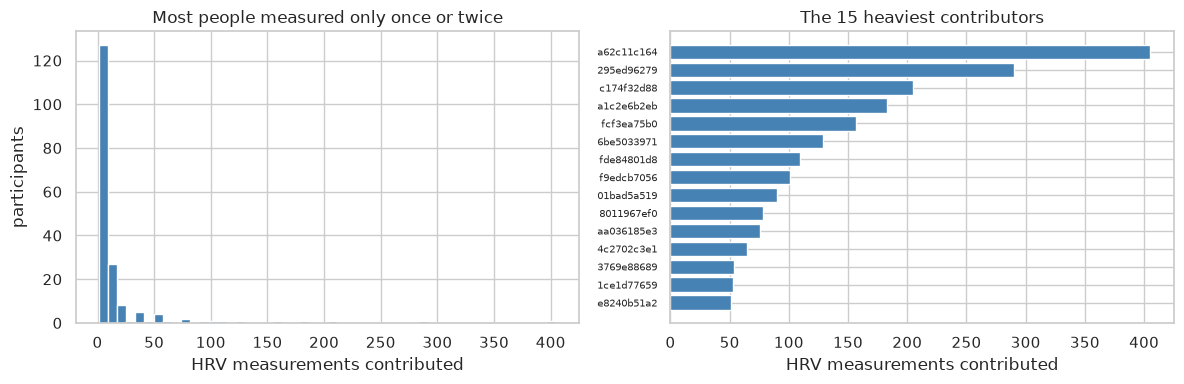

median per participant: 4 | only one measurement: 54 of 185 | top 10 contribute 54% of all rows


In [15]:
per_user = hrv_clean.groupby("user_code").size()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(per_user, bins=50, color="steelblue", edgecolor="white")
ax[0].set_xlabel("HRV measurements contributed")
ax[0].set_ylabel("participants")
ax[0].set_title("Most people measured only once or twice")

top = per_user.sort_values(ascending=False).head(15)
ax[1].barh(range(len(top)), top.values, color="steelblue")
ax[1].set_yticks(range(len(top)))
ax[1].set_yticklabels(top.index, fontsize=7)
ax[1].invert_yaxis()
ax[1].set_xlabel("HRV measurements contributed")
ax[1].set_title("The 15 heaviest contributors")
plt.tight_layout()
plt.show()

print("median per participant:", int(per_user.median()),
      "| only one measurement:", (per_user == 1).sum(), "of", len(per_user),
      "| top 10 contribute", f"{per_user.nlargest(10).sum()/per_user.sum():.0%}", "of all rows")

**This is the most important thing to know about the dataset.** The median participant contributed 4
measurements while the heaviest contributed 405, and the top 10 people account for 54% of all rows.

The consequence is **pseudo-replication**: pooling all 3,245 rows and running a test is not testing 3,245
independent observations, it is mostly testing a handful of people over and over. Any correlation
computed that way would largely describe whoever measured most often. This is why I standardised within
participants, and why a real model on this data would need participant-level grouping.

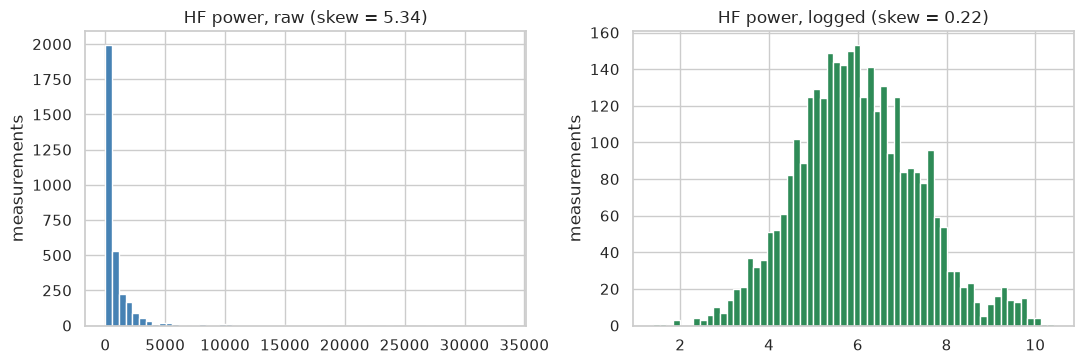

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].hist(hrv_clean["hf"], bins=60, color="steelblue", edgecolor="white")
ax[0].set_title(f"HF power, raw (skew = {hrv_clean['hf'].skew():.2f})")
ax[1].hist(hrv_clean["log_hf"], bins=60, color="seagreen", edgecolor="white")
ax[1].set_title(f"HF power, logged (skew = {hrv_clean['log_hf'].skew():.2f})")
for a in ax:
    a.set_ylabel("measurements")
plt.tight_layout()
plt.show()

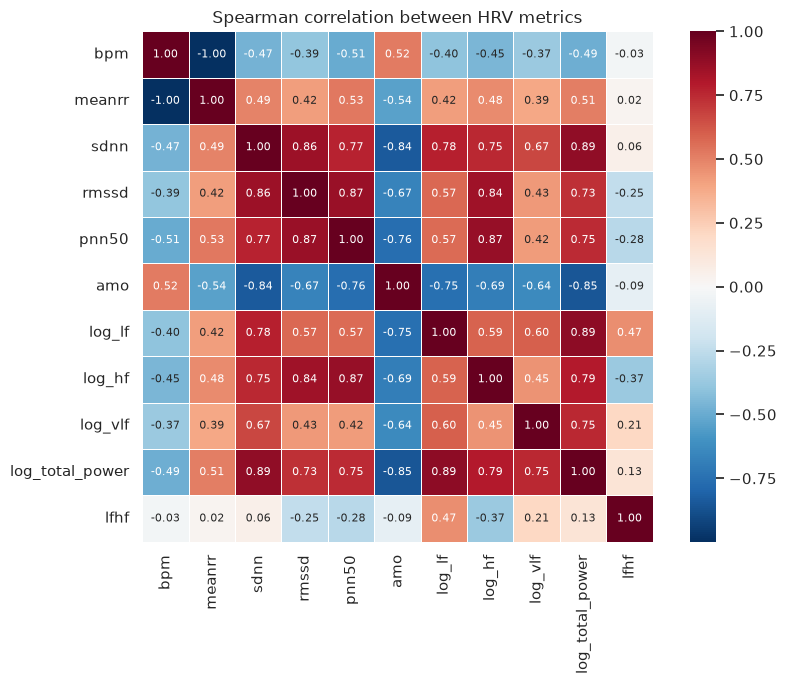

In [17]:
corr_cols = ["bpm", "meanrr", "sdnn", "rmssd", "pnn50", "amo",
             "log_lf", "log_hf", "log_vlf", "log_total_power", "lfhf"]
plt.figure(figsize=(9, 7))
sns.heatmap(hrv_clean[corr_cols].corr(method="spearman"), annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, square=True, linewidths=0.5, annot_kws={"size": 8})
plt.title("Spearman correlation between HRV metrics")
plt.tight_layout()
plt.show()

The raw HF distribution is pressed against the left wall with a long tail; after logging it is close to
symmetric. That is the transform doing the job that deleting "outliers" would have done badly.

For the correlations I used Spearman rather than Pearson, because several of these are still non-linear
with respect to each other even after logging, and Spearman only assumes monotonicity. It confirms the
physiology:

- `bpm` and `meanrr` correlate at -1.00, because one is literally 60000 divided by the other. **Never put
  both in a model.**
- `rmssd`, `pnn50` and `log_hf` form a tight cluster (0.84–0.87) — three names for nearly the same
  parasympathetic quantity.
- `amo` is strongly negative against every HRV measure (-0.84 with `sdnn`), which is what you would
  expect: a rhythm concentrated in one bin means low variability.
- `lfhf` tracks only its own components and is near zero against everything else, so it adds little
  beyond the two numbers it is built from.

So these 11 columns really contain about three independent dimensions.

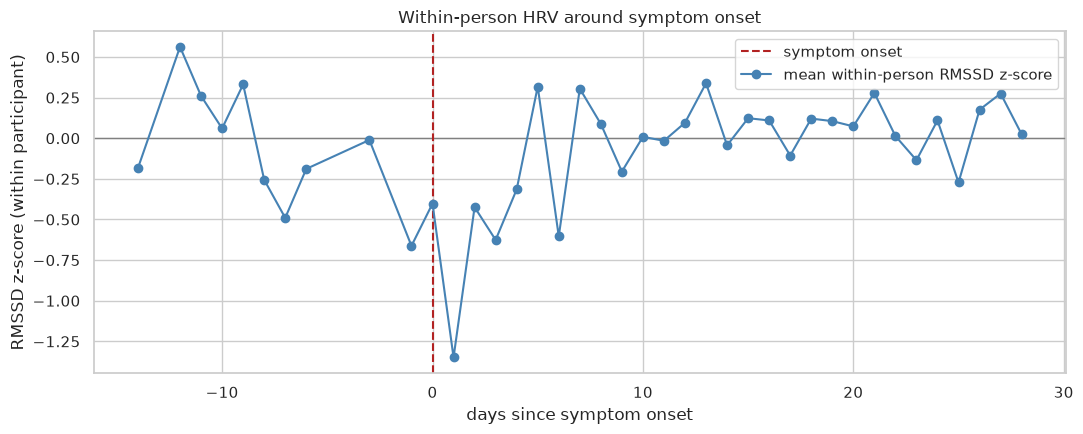

measurements in window: 920 | participants: 51


In [18]:
window = hrv_clean[hrv_clean["days_since_onset"].between(-14, 28) & hrv_clean["rmssd_z"].notna()]
daily = window.groupby("days_since_onset")["rmssd_z"].agg(["mean", "count"])
daily = daily[daily["count"] >= 5]     # drop days driven by only one or two people

plt.figure(figsize=(11, 4.5))
plt.axhline(0, color="grey", linewidth=1)
plt.axvline(0, color="firebrick", linestyle="--", linewidth=1.5, label="symptom onset")
plt.plot(daily.index, daily["mean"], marker="o", color="steelblue",
         label="mean within-person RMSSD z-score")
plt.xlabel("days since symptom onset")
plt.ylabel("RMSSD z-score (within participant)")
plt.title("Within-person HRV around symptom onset")
plt.legend()
plt.tight_layout()
plt.show()

print("measurements in window:", len(window), "| participants:", window["user_code"].nunique())

Each point averages the standardised RMSSD across participants for that day of illness, using only days
with at least 5 measurements so a single person cannot drive a point. There is a visible dip around onset
that recovers over the following weeks.

I want to be careful about how much to read into this. The line is noisy, the mix of participants changes
from day to day, and this is an observational convenience sample with self-reported onset dates. It is a
reasonable exploratory picture, not evidence on its own.

## 11. Summary

185 self-selected Welltory users tracked HRV, symptoms and wearable data between December 2019 and June
2020, to see whether HRV shifts around COVID-19 illness.

**Structurally the data is good** — no orphaned foreign keys, unique participant IDs, no fully duplicated
rows, and the HRV metrics are internally consistent. **The content is where the problems are, and they
are almost all in the self-reported columns:**

| Problem | Scale | What I did |
|---|---|---|
| Onset dates outside the study period (1967–2022) | 13 participants | Rejected before building the timeline feature |
| Duplicate `(user, timestamp)` heart rate readings | 7,330 | Averaged the collisions |
| Impossible heart rates (down to 10 bpm) | 89 | Removed |
| Heights above 220 cm (one at 250 cm) | 2 participants | Set to missing before computing BMI |
| Codebook join key containing `\n\xa0` | 1 key | Stripped before joining |
| Duplicate survey answers in one day | 24 | Kept the later answer |

**The four choices I would defend hardest:**

1. **Not treating -1 and -2 in `how_feel` as missing.** They are Likert scale points; removing them would
   delete the measurements taken when people felt worst, which is the point of the study.
2. **Not imputing the sparse wearable columns.** Their missingness depends on which device someone could
   afford, so imputing would encode income as physiology.
3. **Transforming the skewed metrics instead of deleting outliers.** A 3-sigma rule flagged dozens of rows
   that were merely high, not wrong; logging fixed the distribution without discarding anything.
4. **Standardising within participants.** With 54% of measurements coming from ten people, pooled
   statistics would mostly describe those ten.

**The biggest limitation is not any of the errors above** — those are fixable. It is the sampling: a
self-selected convenience sample, no control group, self-reported COVID status when testing was scarce,
and a median of 4 measurements per person. This dataset supports exploring within-person change over
time. It does not support population-level claims about COVID-19 and HRV.